# Homework 08: exploratory data analysis

**Author:** Paritosh Dwivedi

Profiles the dataset behind my semester project, the Weekly ETF Risk Monitor: **SPY** daily history
paired with **^VIX**, the market's forward volatility index. VIX is derived from S&P 500 option
prices, so it is a derivative-based measure and a natural companion to SPY's realized moves.

The question this feeds is whether next week's SPY volatility looks elevated, so the profiling aims
at that: what the return and volatility distributions look like, how they move together, and what the
time structure implies for stages 09 and 10b.

**Note on layout.** The course structure document lists homework08 as notebook-only, while the stage
08 sheet requires `src/eda.py` and its rubric grades that import. I followed the sheet and created
`src/`, and I flag the discrepancy here as the structure document asks.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install --upgrade pandas   # if an older pandas is already installed

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from scipy.stats import kurtosis, skew

sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Real project data: SPY plus the VIX volatility index ===
raw = yf.download(['SPY', '^VIX'], start='2015-01-01', interval='1d',
                  auto_adjust=False, progress=False)

# SPY and VIX trade on slightly different calendars, so keep the dates both have.
frame = pd.concat(
    [raw['Adj Close']['SPY'], raw['Adj Close']['^VIX'], raw['Volume']['SPY']],
    axis=1,
)
frame.columns = ['spy_close', 'vix_close', 'spy_volume']
df = frame.dropna().reset_index().rename(columns={'Date': 'date'})

df['daily_return'] = df['spy_close'].pct_change()
df['realized_vol_20'] = df['daily_return'].rolling(20).std() * np.sqrt(252)
df['drawdown'] = df['spy_close'] / df['spy_close'].cummax() - 1

# A categorical column the risk decision actually uses, cut on conventional VIX levels.
df['vol_regime'] = pd.cut(df['vix_close'], bins=[-np.inf, 15, 25, np.inf],
                          labels=['calm', 'normal', 'stressed'])
df['day_of_week'] = df['date'].dt.day_name()

print(f'{len(df)} sessions from {df["date"].min().date()} to {df["date"].max().date()}')
df.head()

2926 sessions from 2015-01-02 to 2026-08-21


,date,spy_close,vix_close,spy_volume,daily_return,realized_vol_20,drawdown,vol_regime,day_of_week
0,2015-01-02,169.687805,17.790001,121465900.0,NaN,NaN,0.000000,normal,Friday
1,2015-01-05,166.623383,19.920000,169632600.0,-0.018059,NaN,-0.018059,normal,Monday
2,2015-01-06,165.053940,21.120001,209151400.0,-0.009419,NaN,-0.027308,normal,Tuesday
3,2015-01-07,167.110672,19.309999,125346700.0,0.012461,NaN,-0.015187,normal,Wednesday
4,2015-01-08,170.076080,17.010000,147217800.0,0.017745,NaN,0.000000,normal,Thursday


## 1) First look

In [3]:
df.info(), df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2926 entries, 0 to 2925
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             2926 non-null   datetime64[ns]
 1   spy_close        2926 non-null   float64       
 2   vix_close        2926 non-null   float64       
 3   spy_volume       2926 non-null   float64       
 4   daily_return     2925 non-null   float64       
 5   realized_vol_20  2906 non-null   float64       
 6   drawdown         2926 non-null   float64       
 7   vol_regime       2926 non-null   category      
 8   day_of_week      2926 non-null   object        
dtypes: category(1), datetime64[ns](1), float64(6), object(1)
memory usage: 186.0+ KB


(None,
 date                0
 spy_close           0
 vix_close           0
 spy_volume          0
 daily_return        1
 realized_vol_20    20
 drawdown            0
 vol_regime          0
 day_of_week         0
 dtype: int64)

## 2) Numeric profile

In [4]:
numeric = ['spy_close', 'vix_close', 'spy_volume', 'daily_return', 'realized_vol_20', 'drawdown']
desc = df[numeric].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc.round(4)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
spy_close,2926.0,3.567490e+02,1.610633e+02,1.541616e+02,2.250155e+02,3.209433e+02,4.373324e+02,7.778800e+02,0.7474,-0.4232
vix_close,2926.0,1.835250e+01,6.980800e+00,9.140000e+00,1.371000e+01,1.666000e+01,2.114000e+01,8.269000e+01,2.6429,13.5864
spy_volume,2926.0,8.499999e+07,4.334813e+07,2.027000e+07,5.794260e+07,7.465020e+07,9.795778e+07,5.072443e+08,2.5553,11.1183
daily_return,2925.0,6.000000e-04,1.110000e-02,-1.094000e-01,-3.700000e-03,7.000000e-04,5.900000e-03,1.050000e-01,-0.3069,14.0340
realized_vol_20,2906.0,1.481000e-01,9.730000e-02,3.190000e-02,9.230000e-02,1.236000e-01,1.796000e-01,9.319000e-01,3.7516,22.1417
drawdown,2926.0,-4.090000e-02,5.450000e-02,-3.372000e-01,-5.880000e-02,-1.650000e-02,-2.900000e-03,0.000000e+00,-1.7662,2.7984


Daily returns have kurtosis far above the normal value of zero: fat tails, as expected. Realized
volatility and VIX are both strongly right skewed, so their means sit well above the typical session
and the median is the better summary. Drawdown is bounded above at zero with a long left tail.

## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs
its own look: how many distinct values it has, how lopsided the split is, and whether one
category dominates so heavily that it will be useless as a feature.

`region` is the categorical column in this synthetic set. Your own dataset may have
several — profile all of them.

--- vol_regime ---
            count  proportion
vol_regime                   
normal       1493       0.510
calm         1044       0.357
stressed      389       0.133

--- day_of_week ---
             count  proportion
day_of_week                   
Tuesday        603       0.206
Wednesday      600       0.205
Thursday       590       0.202
Friday         586       0.200
Monday         547       0.187



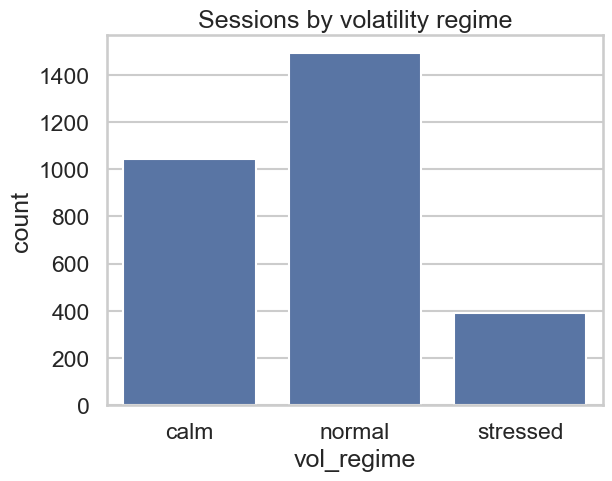

In [5]:
categorical = df.select_dtypes(exclude='number').columns.drop('date')
for column in categorical:
    counts = df[column].value_counts(dropna=False)
    profile = pd.DataFrame({'count': counts, 'proportion': (counts / len(df)).round(3)})
    print(f'--- {column} ---')
    print(profile.to_string(), end='\n\n')

sns.countplot(data=df, x='vol_regime', order=['calm', 'normal', 'stressed'])
plt.title('Sessions by volatility regime')
plt.show()

Most sessions sit in the calm or normal bands and stressed sessions are a clear minority. A raw count
would hide how lopsided that is, which is why the proportion is printed beside it. **A classifier can
score well here by never predicting "stressed"**, so accuracy is the wrong headline metric for stage
10b; balanced accuracy and recall are the ones that mean anything.

Day of week is close to uniform, as it should be. That is a useful negative result: no weekday effect
to engineer around in stage 09.

## 3) Distributions — two worked examples below; add at least one more

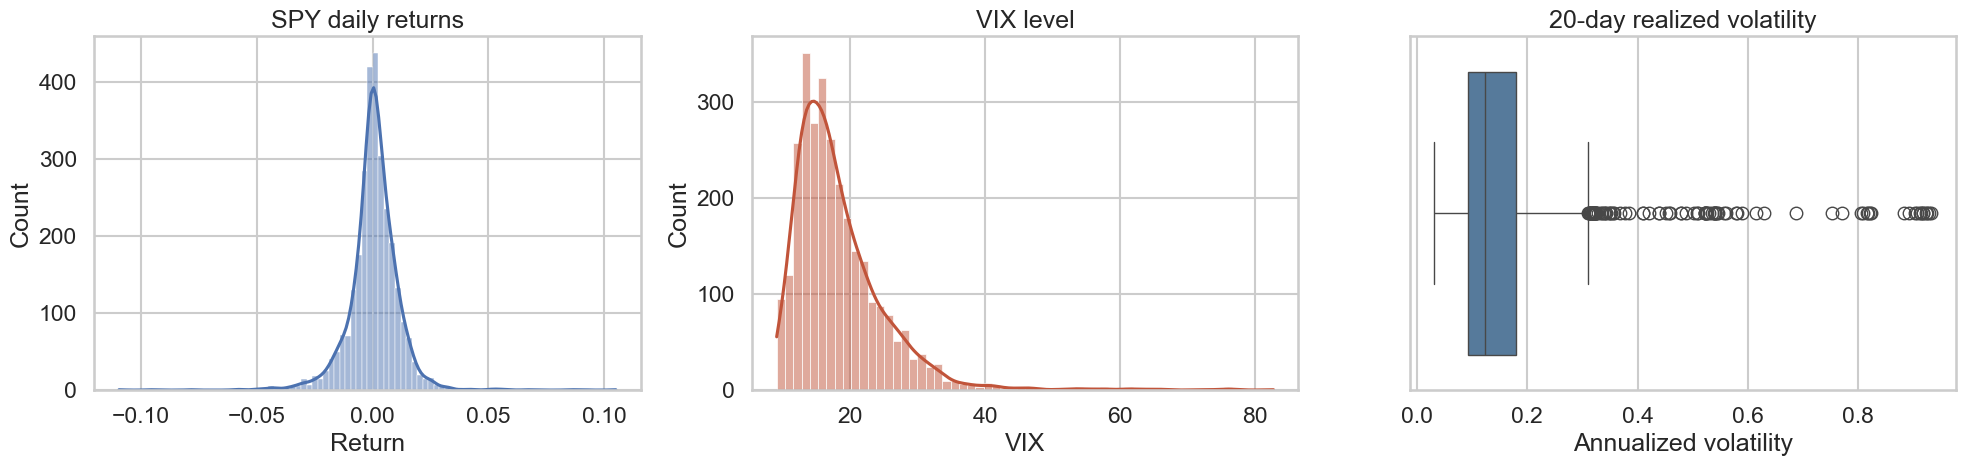

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.histplot(df['daily_return'].dropna(), bins=90, kde=True, ax=axes[0])
axes[0].set(title='SPY daily returns', xlabel='Return')
sns.histplot(df['vix_close'], bins=60, kde=True, ax=axes[1], color='#c1543a')
axes[1].set(title='VIX level', xlabel='VIX')
sns.boxplot(x=df['realized_vol_20'].dropna(), ax=axes[2], color='#4a7ba7')
axes[2].set(title='20-day realized volatility', xlabel='Annualized volatility')
plt.tight_layout()
plt.show()

## 4) Relationships — both are worked below; swap in your own columns

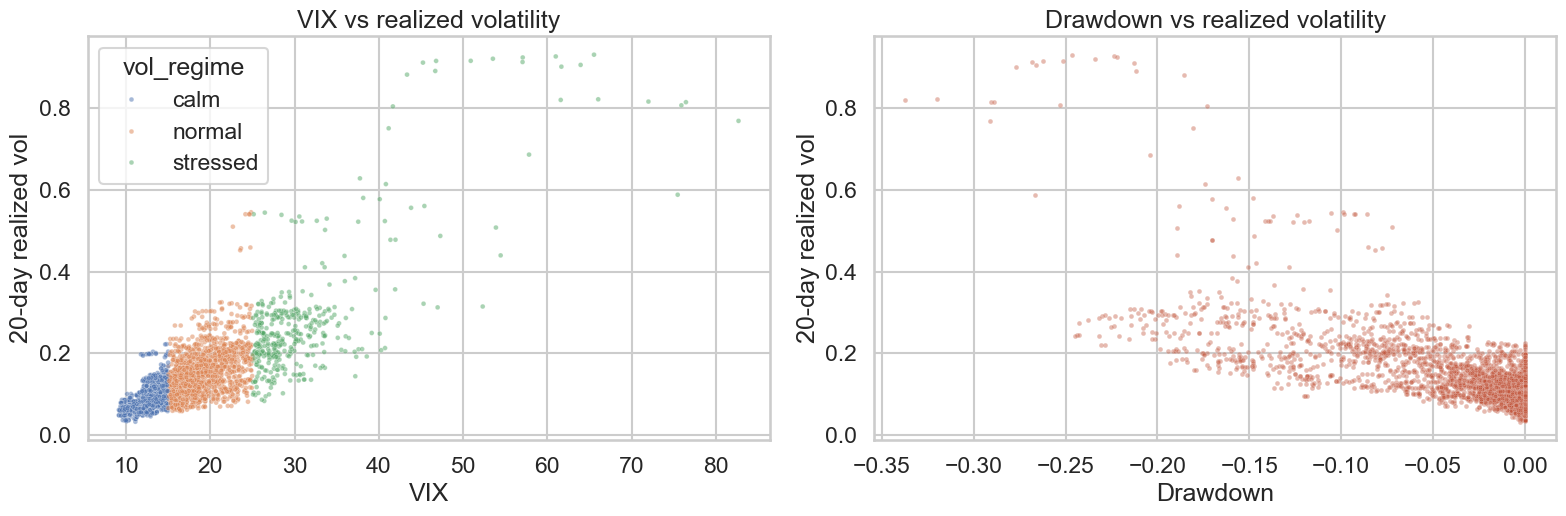

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.scatterplot(data=df, x='vix_close', y='realized_vol_20', hue='vol_regime',
                hue_order=['calm', 'normal', 'stressed'], s=12, alpha=0.5, ax=axes[0])
axes[0].set(title='VIX vs realized volatility', xlabel='VIX', ylabel='20-day realized vol')
sns.scatterplot(data=df, x='drawdown', y='realized_vol_20', s=12, alpha=0.4,
                color='#c1543a', ax=axes[1])
axes[1].set(title='Drawdown vs realized volatility', xlabel='Drawdown',
            ylabel='20-day realized vol')
plt.tight_layout()
plt.show()

VIX and realized volatility rise together, but the relationship curves and fans out at the top: when
VIX is high the range of realized outcomes widens sharply, so an average across that band would
mislead.

Drawdown against realized volatility is the more informative panel. It is asymmetric — deep drawdowns
are always accompanied by high realized volatility, but high volatility does not require a drawdown.
That says drawdown carries information the volatility measures miss, which is why I keep it as its
own feature in stage 09 rather than folding everything into one stress measure.

## 4b) Over time

Nothing above uses the `date` column — and a dataset with a date almost always has
something to say along it: a trend, a seasonal cycle, or a level shift where behaviour
changed.

This is not optional detail. Stage 09 builds lag and rolling features on exactly this
axis, and stage 10b splits the data on it. What you find here decides what those stages
can do — and if the rows are out of order, or there are gaps in the dates, both of
those stages produce nonsense without telling you.

largest gap between sessions: 4 days
gaps longer than 4 days: 0  (holiday weekends)


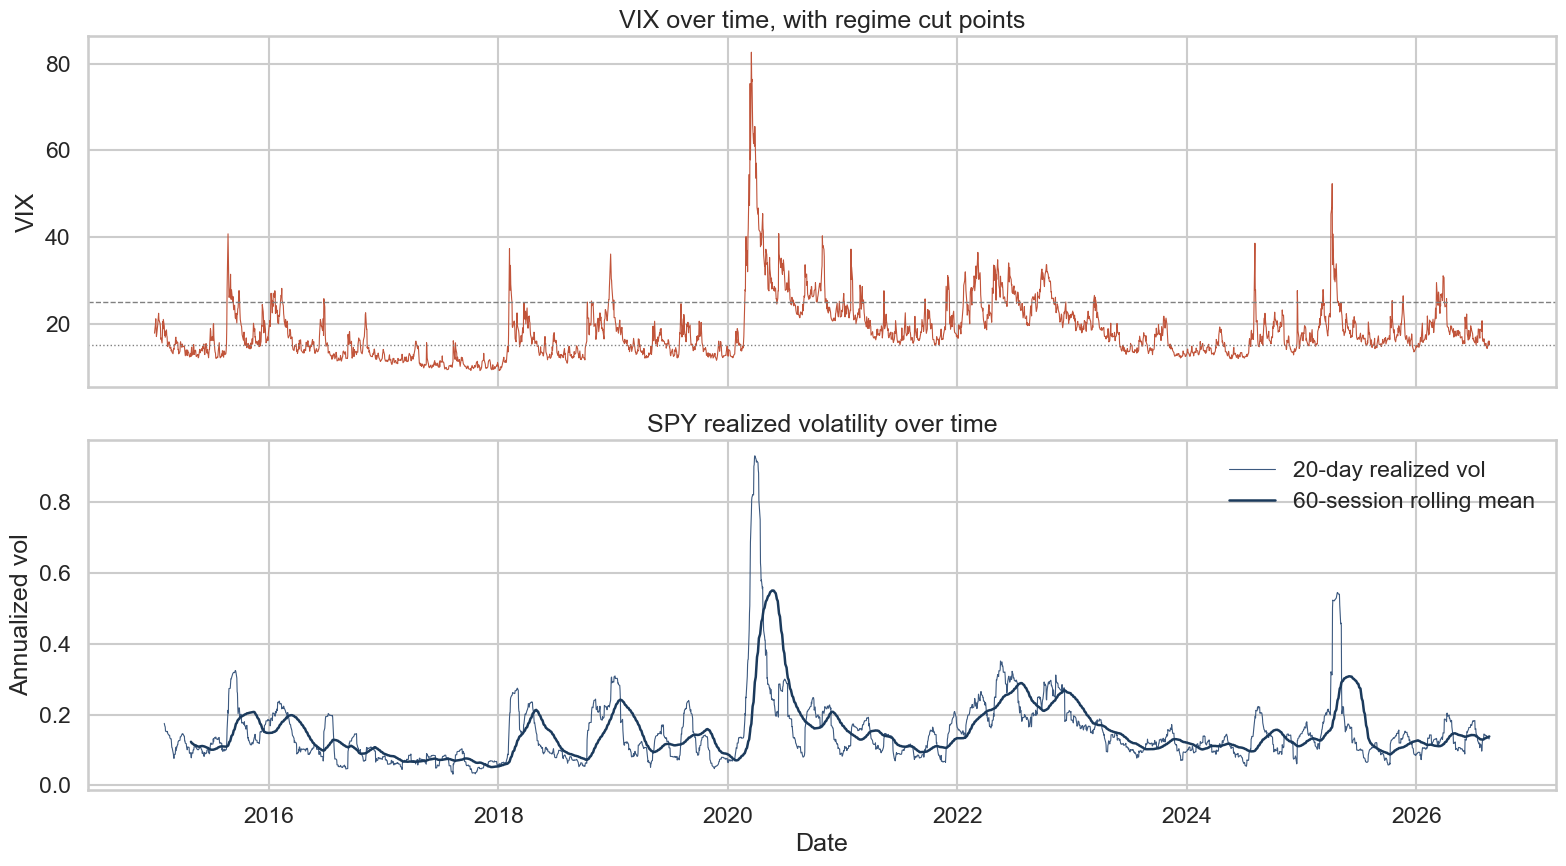

In [8]:
timeline = df.sort_values('date').set_index('date')

gaps = timeline.index.to_series().diff().dt.days
print(f'largest gap between sessions: {int(gaps.max())} days')
print(f'gaps longer than 4 days: {int((gaps > 4).sum())}  (holiday weekends)')

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
axes[0].plot(timeline.index, timeline['vix_close'], linewidth=0.8, color='#c1543a')
axes[0].axhline(15, color='grey', linestyle=':', linewidth=1)
axes[0].axhline(25, color='grey', linestyle='--', linewidth=1)
axes[0].set(title='VIX over time, with regime cut points', ylabel='VIX')

axes[1].plot(timeline.index, timeline['realized_vol_20'], linewidth=0.8,
             color='#3d5a80', label='20-day realized vol')
axes[1].plot(timeline.index, timeline['realized_vol_20'].rolling(60).mean(),
             linewidth=1.8, color='#1b3a5c', label='60-session rolling mean')
axes[1].set(title='SPY realized volatility over time', ylabel='Annualized vol', xlabel='Date')
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

**What I see: no trend, no seasonality, and strong clustering.**

The 60-session rolling mean is flat across a decade. Volatility is mean-reverting around a stable
level rather than drifting, and there is no annual or monthly cycle — spikes land where the news
lands, not on a calendar.

What there is instead is **clustering**: turbulent sessions arrive in runs, most visibly the 2018
volatility spike, the 2020 dislocation, and 2022. The gap check confirms the calendar is clean, with
nothing longer than a holiday weekend, so a rolling window spans the sessions I expect it to.

This drives two decisions:

- **Stage 09** — because volatility is persistent, trailing volatility is the strongest feature
  available, and anything new has to earn its place against it.
- **Stage 10b** — because episodes cluster rather than scatter, a random train/test split would put
  parts of the same episode on both sides and overstate performance badly. The split must be
  chronological.

## 5) (Optional) Correlation matrix

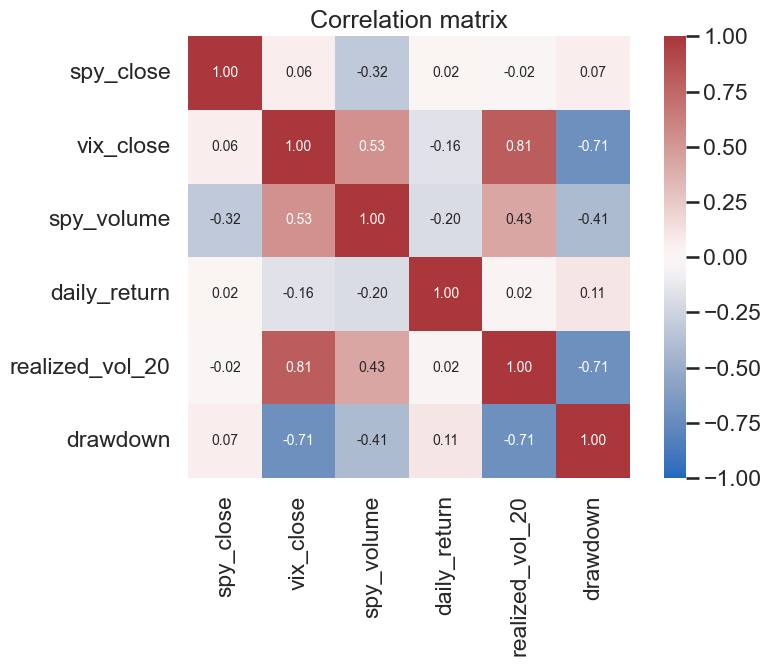

,spy_close,vix_close,spy_volume,daily_return,realized_vol_20,drawdown
spy_close,1.000,0.063,-0.315,0.022,-0.019,0.067
vix_close,0.063,1.000,0.535,-0.163,0.809,-0.715
spy_volume,-0.315,0.535,1.000,-0.196,0.428,-0.407
daily_return,0.022,-0.163,-0.196,1.000,0.024,0.114
realized_vol_20,-0.019,0.809,0.428,0.024,1.000,-0.713
drawdown,0.067,-0.715,-0.407,0.114,-0.713,1.000


In [9]:
corr = df[numeric].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, square=True,
            annot_kws={'size': 10})
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()
corr.round(3)

The pairs that matter: **VIX against realized volatility** is the strong one, confirming VIX is a
genuine signal rather than a restatement of the same number. **Drawdown against realized volatility**
is strongly negative, consistent with the asymmetry above. Daily return correlates with almost
nothing, which is the expected and reassuring result — if it did, tomorrow's direction would be
readable from today's. Volatility is forecastable; direction is not.

## 5b) Your reusable helper — `src/eda.py`

The lecture built `eda_summary(df)` in its section 8. Copy it into `src/eda.py`, import
it here, and call it.

Stage 06 gave your project `src/cleaning.py` and stage 09 will want `src/features.py`.
This is stage 08's contribution to the same set, and the point is that your project keeps
ONE profiling function instead of ten pasted copies of it.

In [10]:
from src.eda import eda_summary

summary = eda_summary(df)
print('shape:', summary['shape'])
print('columns with missing values:', {k: v for k, v in summary['missing'].items() if v})
display(summary['numeric_profile'][['mean', 'std', 'min', 'max', 'skew', 'kurtosis']].round(4))
display(pd.Series(summary['attention'], name='columns').to_frame())

shape: (2926, 9)
columns with missing values: {'daily_return': 1, 'realized_vol_20': 20}


,mean,std,min,max,skew,kurtosis
spy_close,3.567490e+02,1.610633e+02,1.541616e+02,7.778800e+02,0.7474,-0.4232
vix_close,1.835250e+01,6.980800e+00,9.140000e+00,8.269000e+01,2.6429,13.5864
spy_volume,8.499999e+07,4.334813e+07,2.027000e+07,5.072443e+08,2.5553,11.1183
daily_return,6.000000e-04,1.110000e-02,-1.094000e-01,1.050000e-01,-0.3069,14.0340
realized_vol_20,1.481000e-01,9.730000e-02,3.190000e-02,9.319000e-01,3.7516,22.1417
drawdown,-4.090000e-02,5.450000e-02,-3.372000e-01,0.000000e+00,-1.7662,2.7984


,columns
high_missing,[]
near_zero_variance,[]
dominant_category,[]


`eda_summary` reports no high-missingness, near-zero-variance, or dominant-category columns. The only
missing values are structural, at the head of the frame where the 20-session rolling window has not
filled yet.

## 6) Insights & Assumptions (write your commentary)
- TODO: Top 3 insights
- TODO: Assumptions & risks
- TODO: Next steps before modeling (cleaning & features)

## Top three insights

1. **Volatility clusters and mean-reverts; it does not trend or repeat seasonally.** Trailing
   volatility is the feature to beat, and the train/test split must be chronological.
2. **Returns are fat-tailed while VIX tracks realized volatility closely.** Magnitude is
   forecastable from this data; direction is not.
3. **Drawdown relates to volatility asymmetrically.** Deep drawdowns always come with high
   volatility, but high volatility does not require a drawdown, so drawdown adds information the
   volatility family misses.

## Assumptions and risks

- The regime cut points, VIX 15 and 25, are conventional rather than derived from this data. Moving
  them changes the class balance and every classification metric that follows.
- The window starts in 2015, so one broad regime — a long bull market with two sharp shocks — shapes
  most of the profile. These findings may not hold in a sustained high-volatility era.
- Correlations here are linear, and the VIX relationship visibly curves. A low correlation elsewhere
  would not prove independence.
- SPY and VIX were joined on dates both traded, dropping the few sessions where only one did.

## Implications for stage 09

Engineer from the volatility family but expect heavy collinearity and regularize accordingly. Keep
drawdown for its asymmetric information. Encode `vol_regime` as the categorical feature. Build
nothing that reads forward of the decision date, and drop `day_of_week`, which the profile shows is
uniform and carries no signal.